Escolhi usar o dataset dos gambás e criar um classificador entre macho e fêmea 

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abrambeyer/openintro-possum")

print("Path to dataset files:", path)

c:\Users\arthu\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\arthu\.cache\kagglehub\datasets\abrambeyer\openintro-possum\versions\1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 

# Carrega o dataset
df_bruto = pd.read_csv("possum.csv")

Aqui comecei a estudar o dataset, analisar quais são suas colunas, como estão os dados, pra começar a ver o que poderia ser util ou não

In [3]:
display(df_bruto.head())

print(df_bruto.columns)

df_bruto.info()

display(df_bruto.describe())

,case,site,Pop,sex,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
0,1,1,Vic,m,8.0,94.1,60.4,89.0,36.0,74.5,54.5,15.2,28.0,36.0
1,2,1,Vic,f,6.0,92.5,57.6,91.5,36.5,72.5,51.2,16.0,28.5,33.0
2,3,1,Vic,f,6.0,94.0,60.0,95.5,39.0,75.4,51.9,15.5,30.0,34.0
3,4,1,Vic,f,6.0,93.2,57.1,92.0,38.0,76.1,52.2,15.2,28.0,34.0
4,5,1,Vic,f,2.0,91.5,56.3,85.5,36.0,71.0,53.2,15.1,28.5,33.0


Index(['case', 'site', 'Pop', 'sex', 'age', 'hdlngth', 'skullw', 'totlngth',
       'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    object 
 3   sex       104 non-null    object 
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 11.5+ KB


,case,site,age,hdlngth,skullw,totlngth,taill,footlgth,earconch,eye,chest,belly
count,104.000000,104.000000,102.000000,104.000000,104.000000,104.000000,104.000000,103.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,3.625000,3.833333,92.602885,56.883654,87.088462,37.009615,68.459223,48.130769,15.046154,27.000000,32.586538
std,30.166206,2.349086,1.909244,3.573349,3.113426,4.310549,1.959518,4.395306,4.109380,1.050374,2.045597,2.761949
min,1.000000,1.000000,1.000000,82.500000,50.000000,75.000000,32.000000,60.300000,40.300000,12.800000,22.000000,25.000000
25%,26.750000,1.000000,2.250000,90.675000,54.975000,84.000000,35.875000,64.600000,44.800000,14.400000,25.500000,31.000000
50%,52.500000,3.000000,3.000000,92.800000,56.350000,88.000000,37.000000,68.000000,46.800000,14.900000,27.000000,32.500000
75%,78.250000,6.000000,5.000000,94.725000,58.100000,90.000000,38.000000,72.500000,52.000000,15.725000,28.000000,34.125000
max,104.000000,7.000000,9.000000,103.100000,68.600000,96.500000,43.000000,77.900000,56.200000,17.800000,32.000000,40.000000


Agora vim retirando algumas colunas que não ajudariam o modelo como a coluna case que era o id de cada entrada ou a coluna site que dizia onde os gambás foram capturados.
Outras colunas que foram retiradas foram a do tamanho do olho e orelhas, visto que e algo que difere muito pouco entre machos e fêmeas, logo não seria uma informação muito importante pro modelo.

In [ ]:
df_limpo = df_bruto.drop(columns=['site'])
df_limpo = df_limpo.drop(columns=['Pop'])
df_limpo = df_limpo.drop(columns=['case'])
df_limpo = df_limpo.drop(columns=['eye'])
df_limpo = df_limpo.drop(columns=['earconch'])

Agora nas colunas numericas do dataset, vamos analisar o numero de outliers.

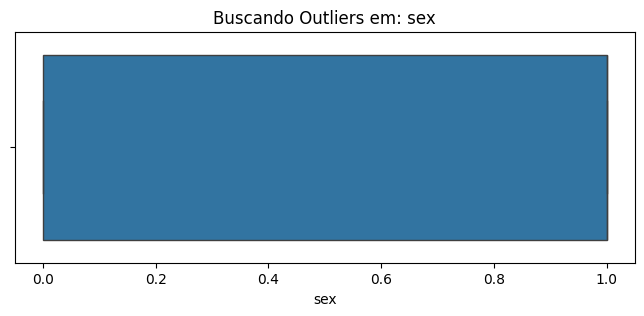

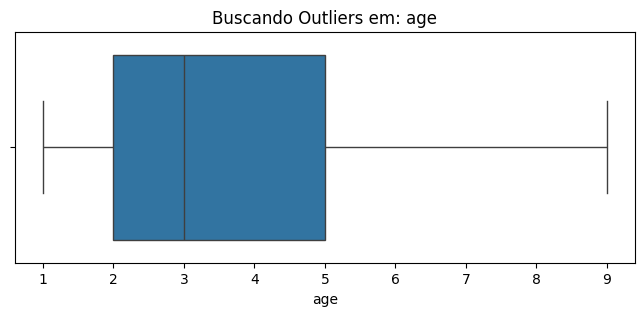

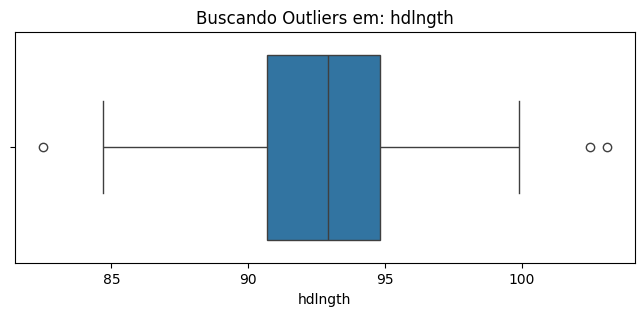

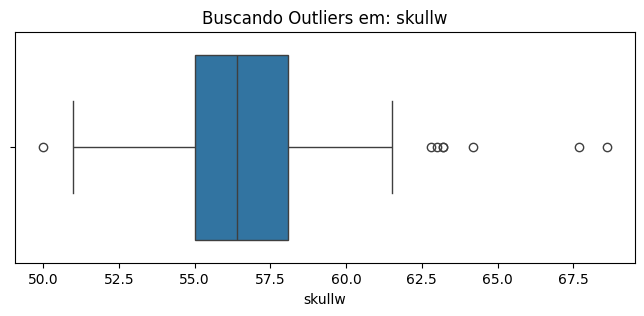

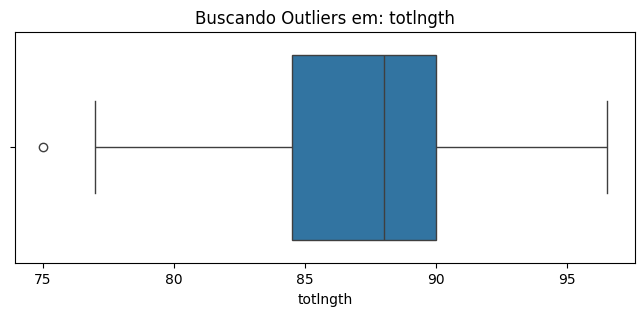

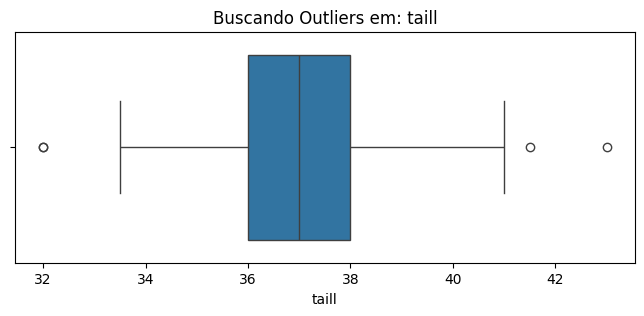

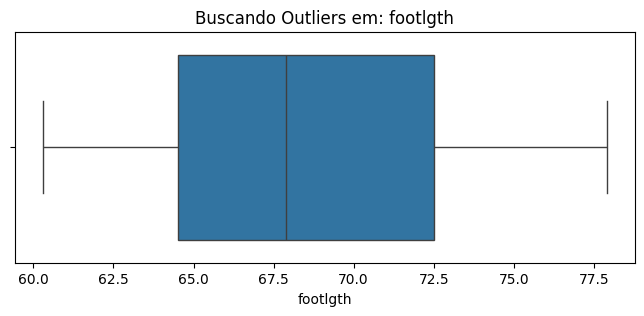

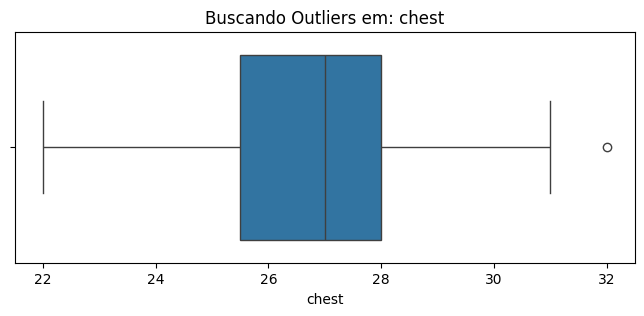

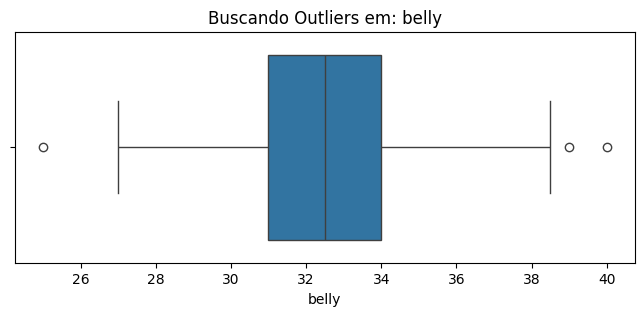

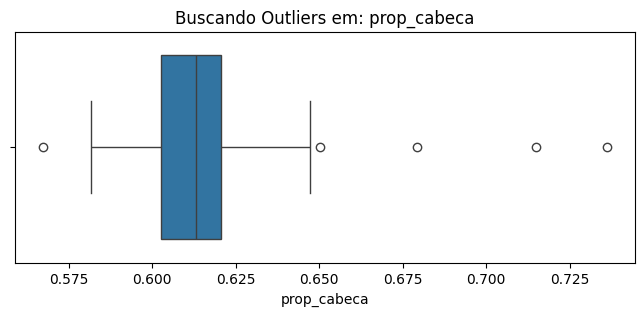

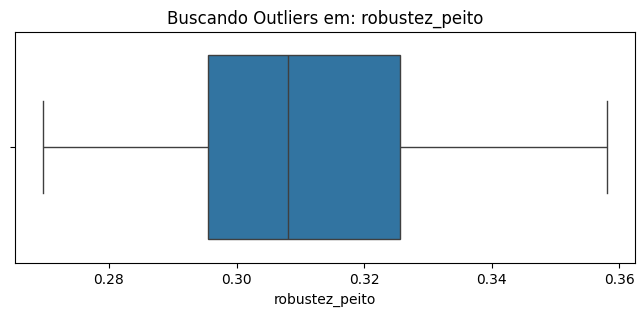

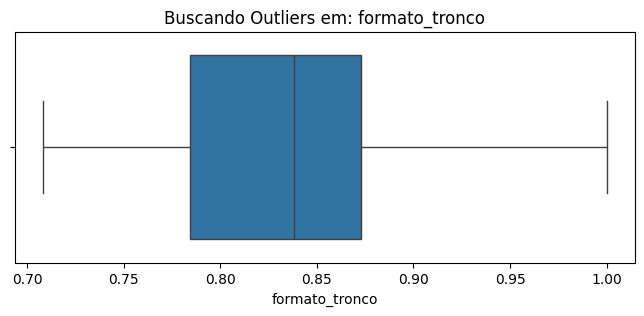

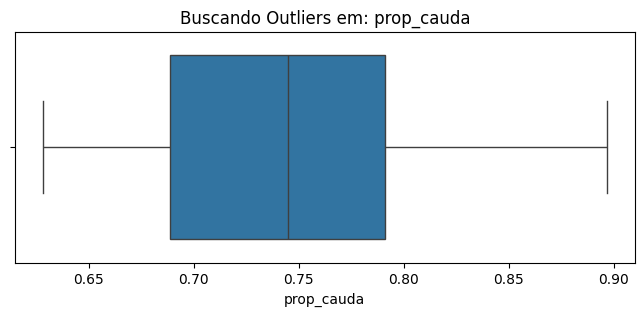

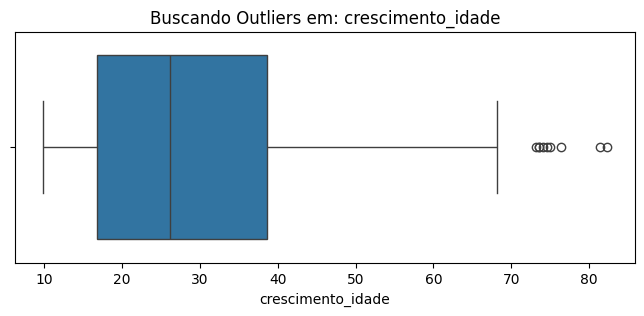

In [15]:
colunas_numericas = df_limpo.select_dtypes(include=['float64', 'int64']).columns
for coluna in colunas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df_limpo[coluna])
    plt.title(f'Buscando Outliers em: {coluna}')
    plt.show()

Optei por manter os outliers por 2 razões:  

1 - Nenhum outlier apresenta um numero absurdo ou biologicamente impossivel o que me faz concluir que sejam apenas individuos com caracteristicas diferentes da maioria.  

2 - Como se trata de dados biologicos, remover o outliers pode fazer com que o modelo consiga interpretar apenas um tipo ideal de gambá, portanto os outliers podem dar uma diversidade maior ao modelo o ensinando que existem individuos diferentes.

Agora precisamos tratar os nossos dados não númericos, no caso so restou o sexo do gambá, aqui simplesmente vamos representar todos os machos pelo numero 1 e as fêmeas pelo 0.

In [16]:
df_limpo['sex'] = df_limpo['sex'].map({'m': 1, 'f': 0})            

Aqui separamos os dados em treino e teste, no caso vamos usar 80% dos dados como treino e o restante como teste.

In [ ]:
from sklearn.model_selection import train_test_split
X = df_limpo.drop(columns=['sex'])
y = df_limpo['sex']   
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42)

Agora chegou o momento de aplicarmos os dados processados em um modelo classificador, o objetivo dessa celula e comparar alguns algoritmos e ver qual se comporta melhor com nossos dados.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

modelos = {
    "Regressão Logística": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
    "SVM": SVC()
}

# 2. Roda um loop para treinar e avaliar cada modelo
print("Comparação de Modelos (Acurácia Média):\n" + "-"*40)

for nome, algoritmo in modelos.items():
    
    # Cria um pipeline: 1º Padroniza a escala, 2º Aplica o algoritmo
    # O StandardScaler transforma todas as colunas para a mesma escala (média 0, desvio 1)
    pipeline = Pipeline([
        ('escalonador', StandardScaler()),
        ('modelo', algoritmo)
    ])
    
    # Aplica Validação Cruzada (divide o treino em 5 partes, treina em 4, testa em 1, e repete)
    # O cv=5 significa 5 dobras (folds)
    scores = cross_val_score(pipeline, X_treino, y_treino, cv=3, scoring='accuracy')
    
    # Calcula a média e o desvio padrão dos resultados
    media = np.mean(scores)
    desvio = np.std(scores)
    
    print(f"{nome}: {media:.4f} (+/- {desvio:.4f})")

Comparação de Modelos (Acurácia Média):
----------------------------------------


InvalidParameterError: The 'cv' parameter of cross_val_score must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 1 instead.

In [9]:
import pandas as pd

# Treina um Random Forest simples com todos os dados de treino
rf = RandomForestClassifier(random_state=42)
rf.fit(X_treino, y_treino)

# Cria uma tabela ranqueando as características da mais importante para a menos
importancias = pd.DataFrame({
    'Caracteristica': X_treino.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

display(importancias)

,Caracteristica,Importancia
1,formato_tronco,0.219777
0,hdlngth,0.218435
4,robustez_peito,0.196178
2,crescimento_idade,0.186441
3,totlngth,0.179169


In [10]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos o Pipeline base (não podemos esquecer de padronizar a escala)
pipeline_svm = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo', SVC())
])

# 2. Definimos o espaço de busca (o grid)
# Nota: Como estamos usando um Pipeline, precisamos colocar 'modelo__' antes do nome do parâmetro
parametros_svm = {
    'modelo__C': [0.1, 1, 10, 50, 100],          # Força da regularização
    'modelo__kernel': ['linear', 'rbf', 'poly'], # Formato da fronteira matemática
    'modelo__gamma': ['scale', 'auto', 0.1, 1]   # Coeficiente do kernel
}

# 3. Configuramos o otimizador (buscando a melhor acurácia usando 5 folds)
grid_svm = GridSearchCV(pipeline_svm, parametros_svm, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Rodamos a busca exaustiva nos dados de treino enxutos (com as 5 colunas)
grid_svm.fit(X_treino, y_treino)

print("=== Resultado da Otimização do SVM ===")
print(f"Melhor Acurácia encontrada: {grid_svm.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_svm.best_params_}")

=== Resultado da Otimização do SVM ===
Melhor Acurácia encontrada: 0.7125
Melhores Parâmetros: {'modelo__C': 10, 'modelo__gamma': 0.1, 'modelo__kernel': 'rbf'}


=== Relatório de Classificação Final (Dados de Teste) ===
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         9
           1       0.67      0.50      0.57        12

    accuracy                           0.57        21
   macro avg       0.58      0.58      0.57        21
weighted avg       0.60      0.57      0.57        21



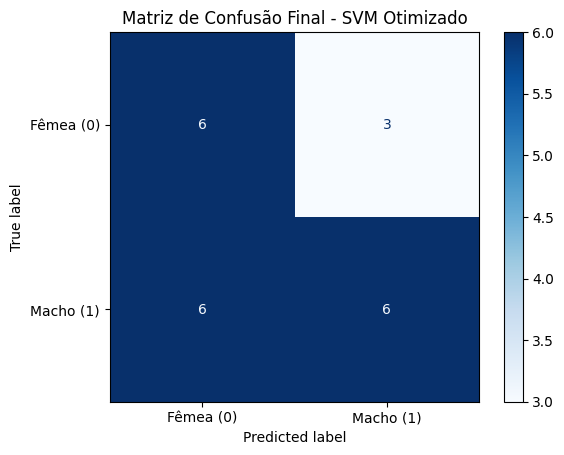

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 2. Faz as previsões nos dados nunca vistos usando o grid otimizado
previsoes_finais = grid_svm.predict(X_teste)

# 3. Imprime o relatório de métricas detalhadas
print("=== Relatório de Classificação Final (Dados de Teste) ===")
print(classification_report(y_teste, previsoes_finais))

# 4. Plota a Matriz de Confusão para vermos os acertos e erros visualmente
matriz = confusion_matrix(y_teste, previsoes_finais)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['Fêmea (0)', 'Macho (1)'])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão Final - SVM Otimizado")
plt.show()

In [ ]:
# 1. Formato da Cabeça (Largura do crânio vs Comprimento da cabeça)
# Machos tendem a ter cabeças mais largas e robustas em proporção ao comprimento.
df_limpo['prop_cabeca'] = df_limpo['skullw'] / df_limpo['hdlngth']

# 2. Índice de Robustez do Peito (Peito vs Tamanho Total)
# Dimorfismo clássico: machos costumam ter a região torácica mais larga.
df_limpo['robustez_peito'] = df_limpo['chest'] / df_limpo['totlngth']

# 3. Formato do Tronco (Peito vs Barriga)
# Compara se o animal tem um formato mais "triangular" (peito maior que barriga) ou "arredondado".
df_limpo['formato_tronco'] = df_limpo['chest'] / df_limpo['belly']

# 4. Proporção da Cauda (Cauda vs Tamanho do Corpo Real)
# Subtraímos a cauda do tamanho total para comparar a cauda apenas com o corpo.
df_limpo['prop_cauda'] = df_limpo['taill'] / (df_limpo['totlngth'] - df_limpo['taill'])

# 5. Desenvolvimento por Idade
# Como você tem a idade, podemos ver a velocidade de crescimento. Machos podem crescer mais rápido.
# (Somamos 0.1 à idade caso exista algum filhote com idade 0, para evitar erro de divisão)
df_limpo['crescimento_idade'] = df_limpo['totlngth'] / (df_limpo['age'] + 0.1)
df_limpo = df_limpo.dropna()

In [ ]:
df_importante = df_limpo[['hdlngth', 'formato_tronco', 'crescimento_idade', 'totlngth', 'robustez_peito','sex']]